In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [12]:
dataset = pd.read_csv("GOOG.csv")

dataset.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,2.490664,2.591785,2.390042,2.499133,2.499133,897427216
1,2004-08-20,2.515820,2.716817,2.503118,2.697639,2.697639,458857488
2,2004-08-23,2.758411,2.826406,2.716070,2.724787,2.724787,366857939
3,2004-08-24,2.770615,2.779581,2.579581,2.611960,2.611960,306396159
4,2004-08-25,2.614201,2.689918,2.587302,2.640104,2.640104,184645512


In [14]:
data = dataset['Open'].values
data = data.reshape(-1,1)

In [16]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [18]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# reshape for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

In [20]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [22]:
model = Sequential()

model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

C:\Users\rutuj\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 154ms/step - loss: 0.0017
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 21s 177ms/step - loss: 4.8875e-05
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - loss: 4.8850e-05
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 18s 146ms/step - loss: 4.7695e-05
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 19s 155ms/step - loss: 4.8697e-05


In [25]:
predicted = model.predict(X_test)

# Convert back to original scale
predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step


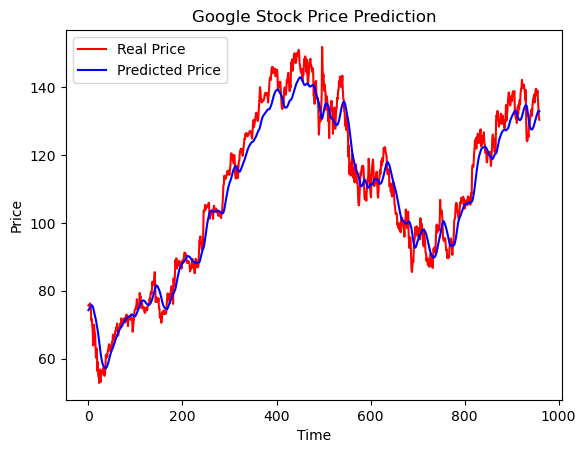

In [26]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [27]:
last_60_days = scaled_data[-60:]
last_60_days = np.reshape(last_60_days, (1,60,1))

next_price = model.predict(last_60_days)
next_price = scaler.inverse_transform(next_price)

print("Next Day Predicted Price:", next_price[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Next Day Predicted Price: 132.5756
